<a href="https://colab.research.google.com/github/kajevic44-sudo/retail_demand_analysis/blob/main/retail_demand_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Projekt 1**

Saving vehicle.csv to vehicle (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-nul

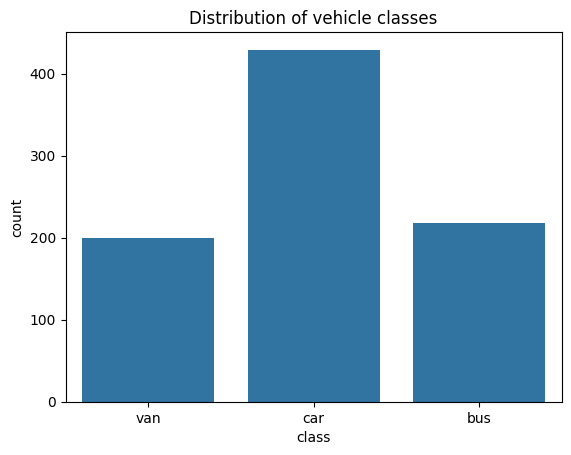

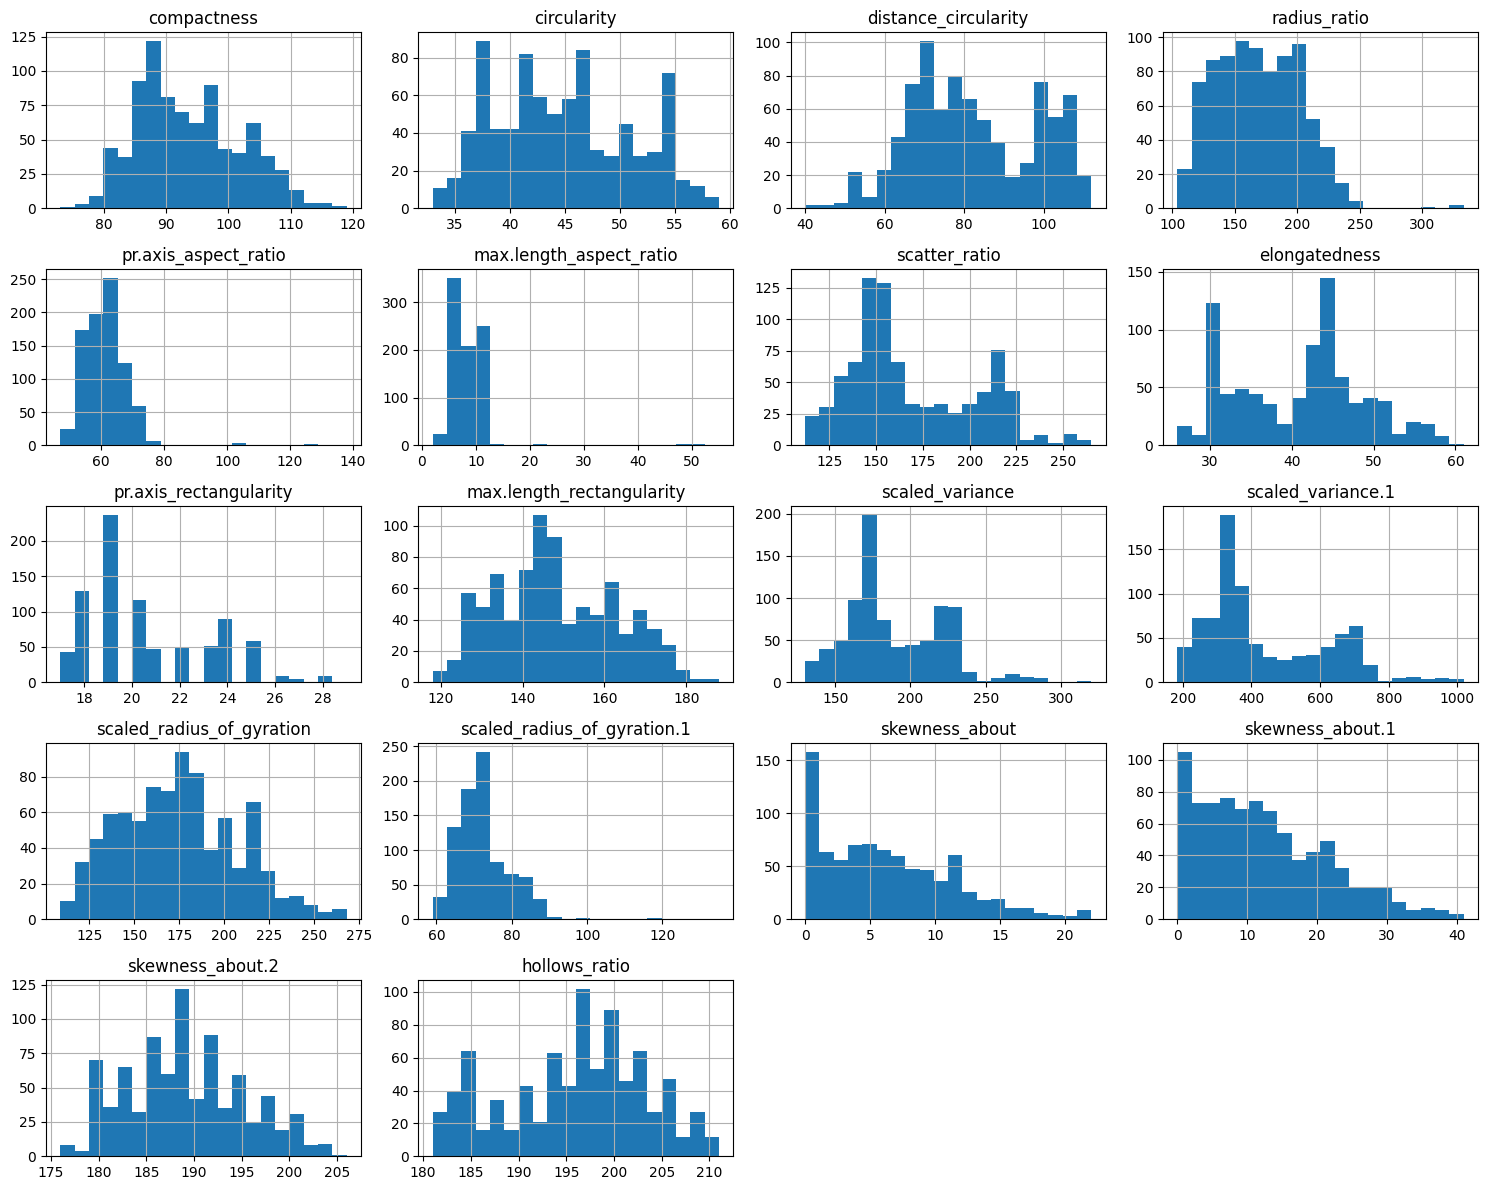

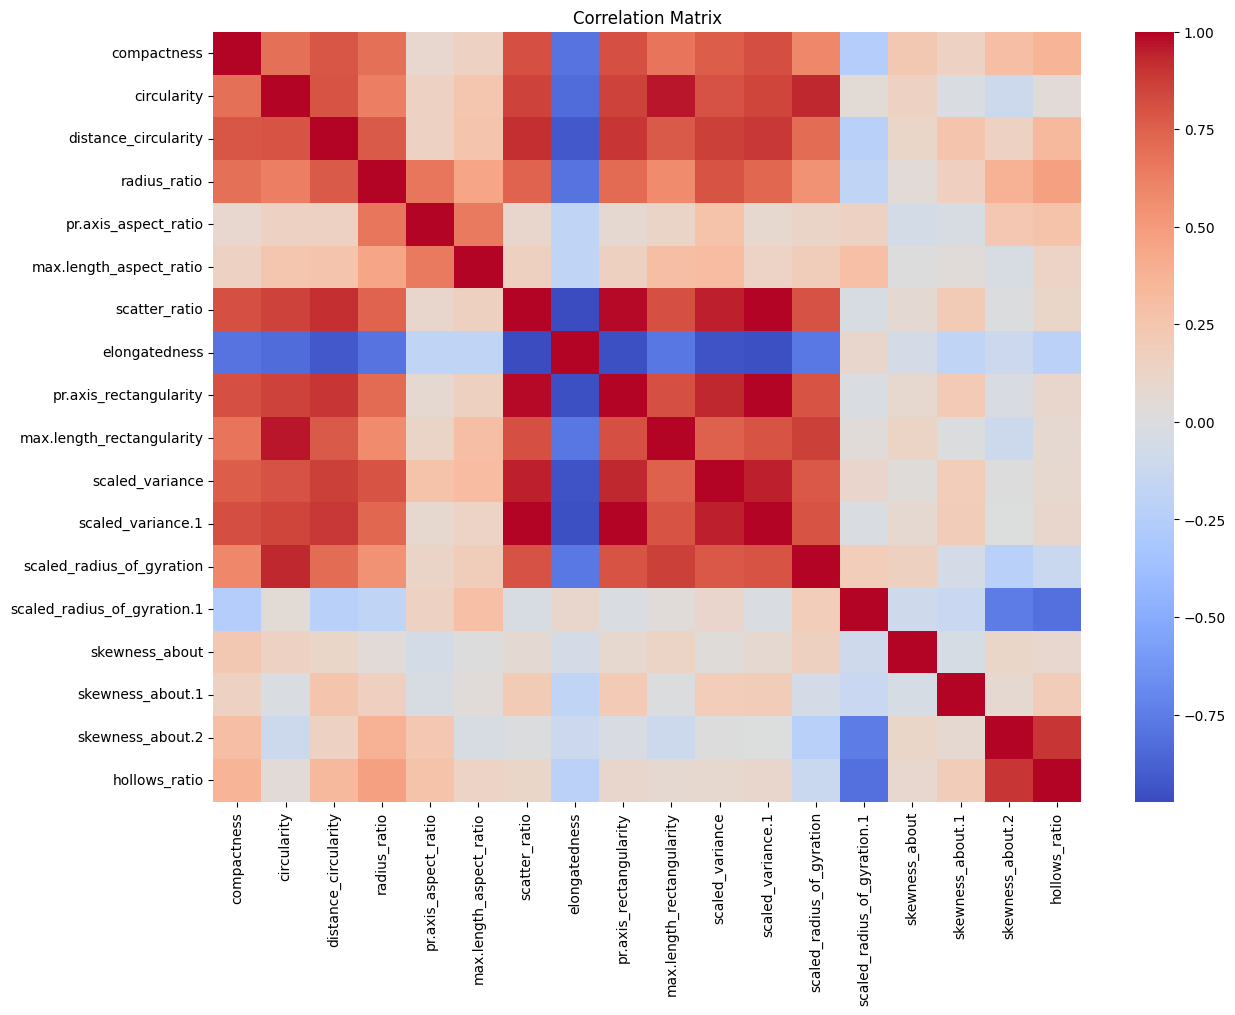

Accuracy: 0.9352941176470588

Classification Report:
               precision    recall  f1-score   support

         bus       0.89      0.95      0.92        44
         car       0.97      0.91      0.94        86
         van       0.91      0.97      0.94        40

    accuracy                           0.94       170
   macro avg       0.93      0.95      0.93       170
weighted avg       0.94      0.94      0.94       170



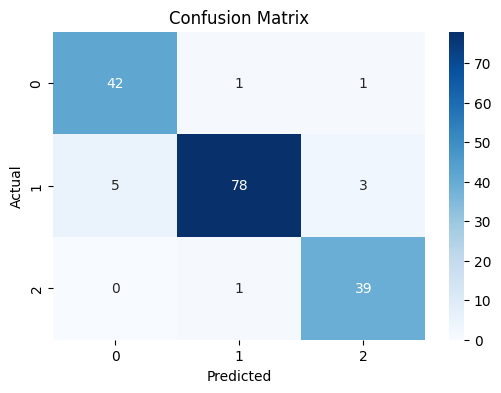

In [ ]:
#Upload dataset
from google.colab import files
uploaded = files.upload()

#Import Pandas
import pandas as pd
import numpy as np

#Read dataset
df = pd.read_csv("vehicle.csv")
df.head()

# check EDA 1st part
#Basic data info
df.info()

# Statistical summary of numerical columns/
df.describe()

# Checking for missing values
df.isna().sum()

# Class distribution (bus / van / car) Eda 2
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='class')
plt.title("Distribution of vehicle classes")
plt.show()

# Feature visualization / Distribution of Numerical Features
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

# Correlation Matrix
numeric_df = df.drop(columns=['class'])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Data Preprocessing
# Imputing NaN values only in numerical columns
df = df.fillna(df.select_dtypes(include=['float64', 'int64']).mean())

X = df.drop('class', axis=1)
y = df['class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training Model
# A
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# B Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Confusion Matriy Analysis
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()








### Clas distribution
The chart shows that the vehicle classes are unevenly distributed. Cars are the most frequent, followed by buses, while vans have the lowest count. This means the dataset is not perfectly balanced, but the difference is not extreme, so the model can still learn effectively.

### Distribution of Numerical Features
The histograms show that different features follow different distributions. Some are approximately symmetrical, while others have distinct peaks or outliers. This is expected, as these represent geometric characteristics of the vehicle silhouettes. It is important to note that all values are numerical and there are no extreme anomalies that would require special preprocessing before modeling.

### Correlation Matrix
The correlation matrix shows that some features are moderately or highly correlated with each other, which is expected since they all describe geometric characteristics of the vehicle silhouette. There are no extremely high correlations that would necessitate the removal of columns, but it is clear that certain groups of features measure similar aspects of the shape. This information is useful for understanding the data structure prior to modeling.

### Data Preprocessing
In this step, I split the dataset into input features (X) and the target variable (y). I then divided the data into training and testing sets using an 80/20 ratio with stratification, ensuring that the class distribution remains consistent across both sets.

Following that, I standardized all numerical features using StandardScaler. Scaling is crucial because models like Logistic Regression and SVM perform better when all variables are on the same scale. This prevents features with larger numerical ranges from dominating the others.

### Training Model (A) and Model Evaluation (B)
The Logistic Regression model achieved a very good result, with an accuracy of approximately 0.94. The classification report shows that the model identifies all three classes (bus, car, van) effectively, with high values for precision, recall, and f1-score.

The highest number of misclassifications occurs within the 'car' class, which is expected as cars share similar geometric characteristics and can overlap with other classes. Nevertheless, the overall performance is stable, demonstrating that the model has successfully learned to distinguish between the vehicle silhouettes.

### Confusion Matrix Analysis
The confusion matrix shows that the model distinguishes between all three vehicle classes very effectively. The highest number of correct predictions (true positives) is in the 'car' class, though there are a few instances where cars were misclassified as 'bus' or 'van'.

The 'bus' class has very few errors (only 2 misclassifications), while the 'van' class is also stable with only a single misclassified instance.

These results confirm that the model generalizes well and that errors are minimal and expected, given the similarities in geometric characteristics between certain classes.

### Final Project Conclusion
This project analyzed vehicle silhouettes with the objective of automatically classifying three types of vehicles: bus, car, and van. Following data loading and inspection, an Exploratory Data Analysis (EDA) revealed that all features are numerical, with the class being the only categorical variable. The class distribution is slightly imbalanced, but not to an extent that would significantly compromise model performance.

Histograms showed that different features follow various distributions, which is expected for geometric characteristics of a silhouette. The correlation matrix revealed that certain features measure similar aspects of shape, though no extreme correlations were found that would necessitate column removal.

The data was then split into training and testing sets, with numerical values standardized to ensure a uniform scale for all features. Logistic Regression was used as the initial supervised model, achieving very strong results.

Model evaluation showed an accuracy of approximately 94%, indicating that the model successfully distinguishes between the three vehicle classes. The confusion matrix confirmed that errors are minimal and expected, occurring primarily within the 'car' class, which shows the most overlap with others.

Overall, the model is stable, generalizes well, and serves as a high-quality baseline for further work. These results demonstrate that geometric silhouette characteristics are sufficiently informative for vehicle classification, and the project successfully showcases a complete machine learning workflow: from EDA and data preparation to model training and evaluation.

SVM Accuracy: 0.9705882352941176

SVM Classification Report:
               precision    recall  f1-score   support

         bus       0.98      1.00      0.99        44
         car       0.99      0.95      0.97        86
         van       0.93      0.97      0.95        40

    accuracy                           0.97       170
   macro avg       0.96      0.98      0.97       170
weighted avg       0.97      0.97      0.97       170



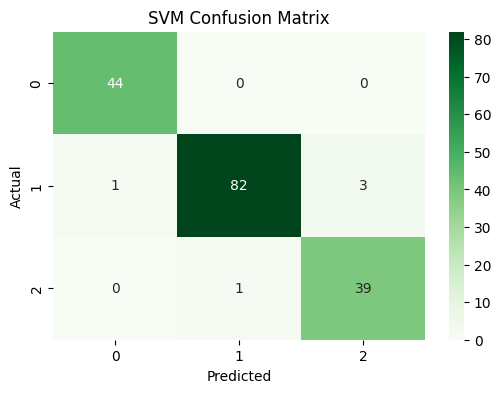

In [ ]:
##### Extension 1

### SVM model (RBF kernel) Performarce

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

## Confusion Matrix (SVM) Analysis
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### Extension 1. SVM Model Performance
The SVM model with an RBF kernel achieved the best results so far, with an accuracy of approximately 0.97. The model separates the classes very effectively in the scaled feature space and shows high precision, recall, and f1-score values across all three classes.

The best performance is observed in the 'bus' class, while minimal errors are present in the 'car' class, which is expected due to the similarity of geometric characteristics. SVM has proven to be a highly effective model for this type of data.

### Extension 1. SVM Confusion Matrix Analysis
The SVM confusion matrix shows that the model classifies all three vehicle classes exceptionally well. The 'bus' class is identified with perfect accuracy, without a single error, while minimal misclassifications are present in the 'car' and 'van' classes.

These results confirm that the SVM with an RBF kernel effectively separates the classes in the scaled feature space, making it one of the strongest models in this project. Errors are rare and expected due to the overlap in geometric characteristics between certain vehicle types.

Random Forest Accuracy: 0.9588235294117647

Random Forest Classification Report:
               precision    recall  f1-score   support

         bus       0.96      1.00      0.98        44
         car       0.99      0.93      0.96        86
         van       0.91      0.97      0.94        40

    accuracy                           0.96       170
   macro avg       0.95      0.97      0.96       170
weighted avg       0.96      0.96      0.96       170



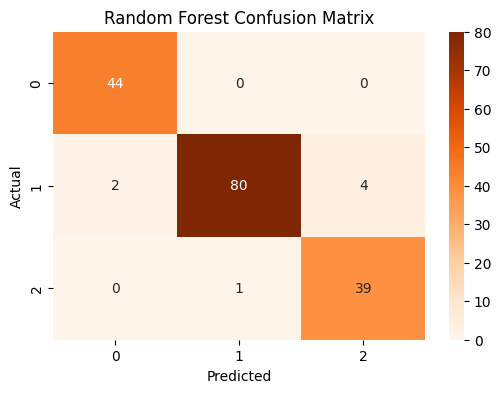

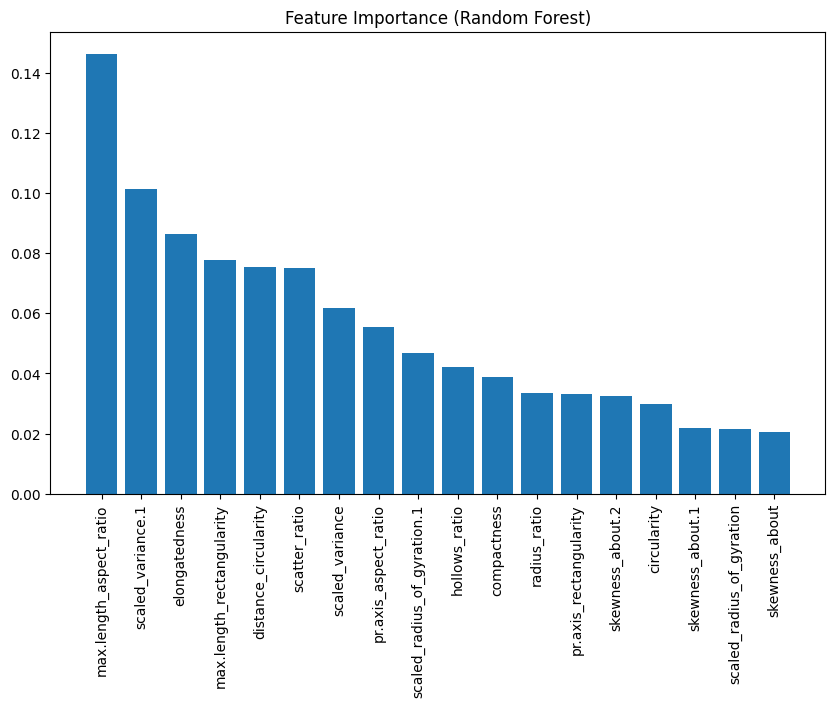

In [ ]:
##### Extension 2.

### RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

### Cusotm Matrix RF
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Feature Importance RF
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()




### Extension 2: Random Forest Model Performance
The Random Forest model achieved very strong results, with an accuracy of approximately 0.96. The model is robust, generalizes well, and shows stable precision, recall, and f1-score values across all three classes.

The 'bus' class is recognized almost perfectly, while most errors occur within the 'car' class, which is expected due to the overlap in geometric characteristics between cars and other vehicles. Random Forest has proven to be a powerful model that performs well even without data scaling.

### Extension 2: Random Forest Confusion Matrix Analysis
The confusion matrix for Random Forest shows that the model classifies all three classes very effectively. The 'bus' class is identified with perfect accuracy, without a single error, while most misclassifications occur within the 'car' class—which is expected due to the overlap in geometric characteristics between cars and other vehicles.

The 'van' class is also stable, with only a single misclassified instance. These results confirm that Random Forest is a robust model that generalizes well and provides reliable performance, even without feature scaling.

### Extension 2: Feature Importance Analysis
The Feature Importance chart illustrates the relative significance of each attribute within the Random Forest model's decision-making process. The model assigns higher importance to the features that contribute most to the separation of classes (bus, car, van).

It is evident that certain geometric parameters have a significantly greater impact than others, indicating that specific dimensions and silhouette shapes carry key information for vehicle classification. This visualization allows for better model interpretability and provides insight into which features influence performance the most.

In [ ]:
##### Extension 3

## Model Comparison
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Logistic Regression Accuracy: 0.9352941176470588
SVM Accuracy: 0.9705882352941176
Random Forest Accuracy: 0.9588235294117647


### Extension 3: Model Comparison
By comparing the three models (Logistic Regression, SVM, and Random Forest), the difference in performance is clearly visible. Logistic Regression provides a stable baseline with approximately 0.93 accuracy, while Random Forest achieves a better result of around 0.96, thanks to its robustness and ability to capture non-linear relationships.

The best performance is achieved by the SVM model with an RBF kernel, reaching an accuracy of approximately 0.97. This model separates the classes most effectively in the scaled feature space and demonstrates the most stable precision, recall, and f1-score values.

The conclusion is that while all three models are successful, SVM provides the most precise results for this dataset, whereas Random Forest offers additional interpretability through feature importance.

### Final Project Conclusion with Extensions 1, 2 and 3
## Additional Conclusion (Following Model Expansion)
This project successfully implemented the complete workflow for classifying vehicle types (bus, car, van) based on the geometric characteristics of their silhouettes. Following the initial Exploratory Data Analysis (EDA), data preparation, and standardization, multiple models were trained to obtain a comprehensive performance assessment.

Logistic Regression served as a stable baseline with an accuracy of approximately 0.93. The SVM model with an RBF kernel proved to be the most successful, achieving an accuracy of about 0.97 and the most consistent precision, recall, and f1-score values. Random Forest also yielded excellent results (around 0.96 accuracy), with the added benefit of interpretability through feature importance analysis.

Confusion matrices across all models indicate that errors are minimal and primarily occur within the 'car' class, which is expected due to overlapping geometric features. Furthermore, the feature importance analysis confirms that specific silhouette attributes play a dominant role in the classification process.

The conclusion is that all models successfully resolved the task; SVM stood out as the most precise, while Random Forest offered the best balance between performance and interpretability. This project demonstrates a complete machine learning pipeline and serves as a solid foundation for further improvements or real-world applications.

**Projekt 2**

# Project 2 — Unsupervised Learning Approach

In this project, we revisit the same business problem from Project 1:  
**Prospect Auto needs a model that can distinguish between three vehicle types (bus, car, van) based on silhouette geometry.**

However, unlike Project 1, where supervised learning used labeled data,  
**Project 2 explores whether unsupervised learning can uncover meaningful structure without using labels during training.**

This project includes:
- Data preprocessing (scaling)
- Dimensionality reduction using PCA
- Clustering using KMeans
- Evaluation using unsupervised and supervised-aligned metrics
- Comparison with supervised results from Project 1


In [ ]:
# ============================================================
# PROJECT 2 — UNSUPERVISED LEARNING (Prospect Auto)
# ============================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix


In [ ]:
###Load Dataset
# Load the same dataset from Project 1
df = pd.read_csv("vehicle.csv")

# Optional: preview
df.head()


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [ ]:
### Data Preparation
# Separate features and labels

df.columns

X = df.drop("class", axis=1)
y = df["class"]


# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Data Preparation Summary

All features were scaled using StandardScaler to ensure equal contribution to distance-based algorithms such as PCA and KMeans.  
The target column (`class`) was separated but not used during training, as this is an unsupervised learning task.


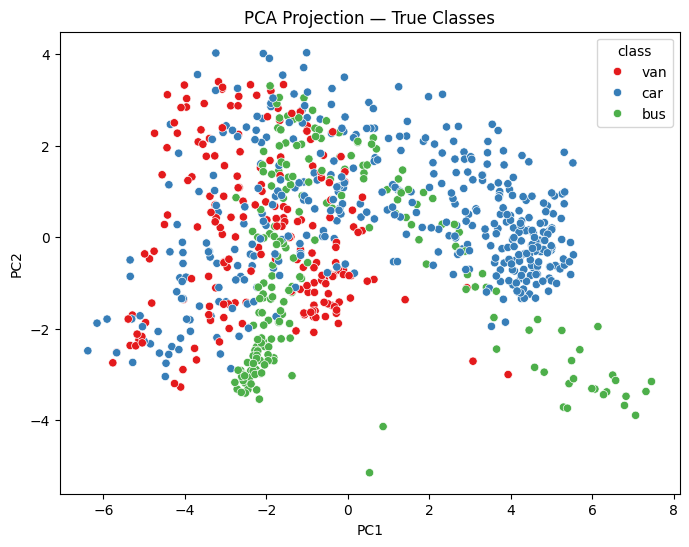

In [ ]:
###PCA - Dimensionality Reduction

#NAN check
df.isna().sum()

#Nan remove
df = df.dropna()

X = df.drop("class", axis=1)
y = df["class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
pca.explained_variance_ratio_

##Visualisation PCA
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1")
plt.title("PCA Projection — True Classes")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()







### PCA Results and Interpretation

PCA reduced the original 18-dimensional feature space to 2 principal components.

The explained variance ratio was:
- PC1: **52.45%**
- PC2: **16.59%**

Together, the first two components capture **approximately 69%** of the total variance.

This indicates that PCA provides a meaningful low-dimensional representation of the data, suitable for visualization and clustering analysis.


### PCA Visualization — True Classes

The PCA projection shows partial structure in the data.  
Some separation is visible between classes, but there is still significant overlap.  
This suggests that the geometric features contain useful information, but the classes are not perfectly separable in a 2D space.


In [ ]:
###KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


### KMeans Clustering Summary

KMeans was applied with **3 clusters**, matching the number of vehicle classes.  
The algorithm assigned each sample to a cluster based solely on geometric similarity, without using labels.


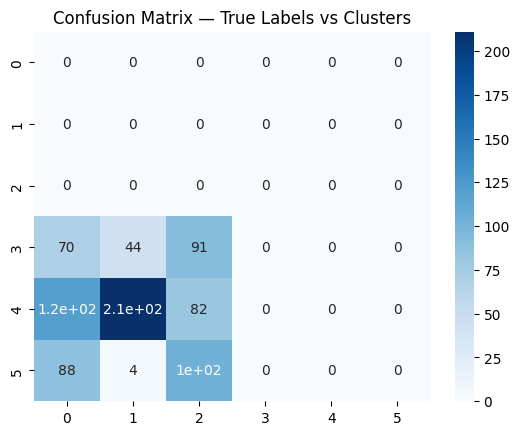

In [ ]:
###Evaluation Metrics
# Silhouette Score (čisto unsupervised)
silhouette = silhouette_score(X_scaled, clusters)
silhouette

#ARI and NMI (comparation with class)
ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

ari, nmi

#Confusion Matrix
clusters_str = clusters.astype(str)

cm = confusion_matrix(y, clusters_str)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix — True Labels vs Clusters")
plt.show()




### Clustering Evaluation

The clustering performance metrics were:

- **Silhouette Score:** 0.29  
  Indicates weak cluster separation.

- **Adjusted Rand Index (ARI):** 0.10  
  Shows very low agreement between clusters and true labels.

- **Normalized Mutual Information (NMI):** 0.11  
  Suggests minimal shared information between clusters and actual classes.

These results confirm that the unsupervised clusters do not align well with the true vehicle categories.


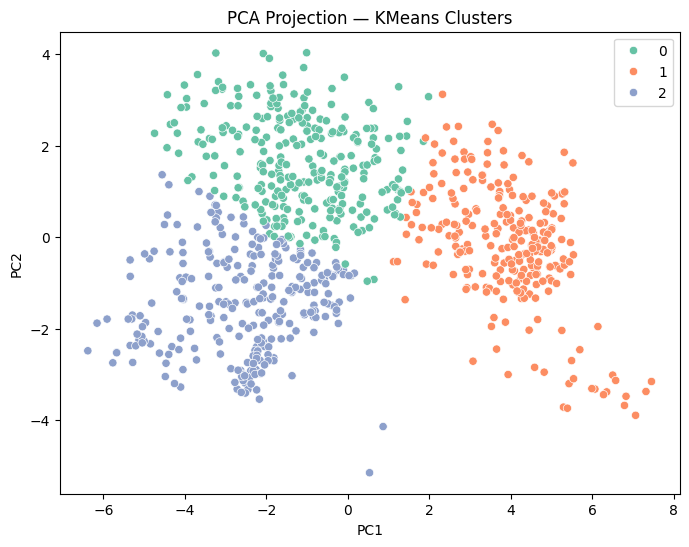

In [ ]:
###PCA Visualisation Clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set2")
plt.title("PCA Projection — KMeans Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### PCA Visualization - KMeans Clusters

The PCA projection of KMeans clusters shows significant overlap between the three groups.  
Cluster 0 and Cluster 2 partially separate, but Cluster 1 is widely dispersed and overlaps with both.  
This visual pattern aligns with the low silhouette, ARI, and NMI scores.


## Conclusions - Unsupervised Learning (Project 2)

- PCA successfully reduced dimensionality while preserving most of the variance.
- KMeans clustering revealed weak structure in the data, with significant overlap between clusters.
- Evaluation metrics (Silhouette = 0.29, ARI = 0.10, NMI = 0.11) indicate that clusters do not correspond well to true vehicle classes.
- Unsupervised learning provides insight into the geometric relationships between samples but is not suitable for accurate vehicle classification in this case.


## Comparison with Project 1 (Supervised Learning)

- Supervised models (especially SVM with 0.97 accuracy) performed significantly better because they used labeled data.
- Unsupervised clustering struggled to recover the true class structure, showing weak alignment with actual labels.
- PCA helped visualize the data but did not reveal clearly separable groups.
- This comparison highlights that **supervised learning is the appropriate approach** for Prospect Auto’s classification problem, while unsupervised learning is useful for exploratory insight.


**Final Business Conclusion**

## Business Conclusion for Prospect Auto

Supervised learning remains the best solution for automatic vehicle classification, offering high accuracy and reliable predictions.  
Unsupervised learning, while not suitable for deployment, provides valuable exploratory insight into the geometric structure of the data.  
Together, both approaches deepen our understanding of the problem and confirm that labeled data is essential for achieving strong performance in this task.


Results

In [ ]:
pca.explained_variance_ratio_

silhouette

ari, nmi

